<a href="https://colab.research.google.com/github/annjgs/Espectrometo-optico-de-centelleo/blob/main/Tarea_6_derivadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Codigo

In [ ]:
%%writefile ejercicio.cpp

#include <iostream>
#include <cmath>
#include<vector>
#include <iomanip>      //Control de salida para cifras significativas

using namespace std;

double A = 2;
double b = 3;
double c = 4;

double F(double x) {         //funcion a derivar
 return A*exp(-(pow((x-b),2))/(2*(pow(c,2))));
}

double F_derivada(double x) {         // funcion derivada exacta
    return A * exp(-(pow((x - b), 2)) / (2 * pow(c, 2))) * (-(x - b) / pow(c, 2));
}
double F_derivada_centrada(double x, double h) {
 return (F(x+(h/2))-F(x-(h/2)))/(h);
}

double F_derivada_adelante(double x, double h) {
 return (F(x+h)-F(x))/(h);
}

double F_derivada_extrapolada(double x, double h) {
  double cd_half = (F(x + h / 4) - F(x - h / 4)) / (h / 2) ;
  double cd_full = (F(x + h / 2) - F(x - h / 2)) / h ;
    return (4 * cd_half - cd_full) / 3;
}


int main(){
//lista de valores de x
    int n = 500;
    double inicio = 0;
    double fin = 20;

    vector<double> x;

    double paso = (fin - inicio) / (n - 1);

    for (int i = 0; i < n; i++) {
        x.push_back(inicio + i * paso);
    }

//valor del h

double h = 0.1 ;


//resultados derivada real

vector<double> real;
for (int i = 0; i < n; i++) {
    real.push_back(F_derivada(x[i]));
}

//resultados derivada centrada

vector<double> centrada;
for (int i = 1; i < n-1; i++) {
    centrada.push_back(F_derivada_centrada(x[i], h));
}


//resultados derivada adelante

vector<double> adelante;
for (int i = 1; i < n-1; i++) {
    adelante.push_back(F_derivada_adelante(x[i], h));
}


//resultados derivada extrapolada

vector<double> extrapolada;
for (int i = 1; i < n-1; i++) {
    extrapolada.push_back(F_derivada_extrapolada(x[i], h));
}

cout << std::setprecision(15);      //Colocar la mayor parte de las cifras para apreciar mejor el error

for (int i = 1; i < n-1; i++) {    //Dominio centrado en donde existen las 3 formas de derivacion numerica para mejores graficas
    cout << x[i] <<" "
         << real[i]<<  " "
         << centrada[i-1] << " "
         << adelante[i-1] << " "
         << extrapolada[i-1]
         <<endl;
}
return 0;
}




Overwriting ejercicio.cpp


##Compilador

In [ ]:
!g++ ejercicio.cpp -o ejercicio

##Resultados

In [ ]:
!./ejercicio > resultado.txt

#Graficacion en python

/tmp/ipykernel_1530/2549584997.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("resultado.txt", delim_whitespace=True, header=None)


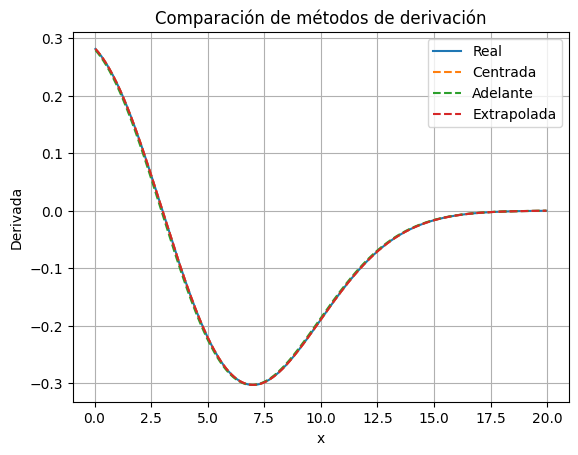

Text(0.5, 1.0, 'Comparación Error de métodos de derivación')

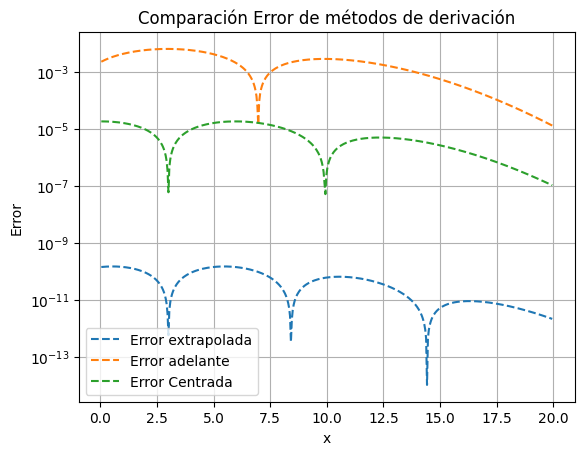

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("resultado.txt", delim_whitespace=True, header=None)

df.columns = ["x", "real", "centrada", "adelante", "extrapolada"]


plt.plot(df["x"], df["real"], label="Real", linestyle="-")
plt.plot(df["x"], df["centrada"], label="Centrada", linestyle="--")
plt.plot(df["x"], df["adelante"], label="Adelante", linestyle="--")
plt.plot(df["x"], df["extrapolada"], label="Extrapolada", linestyle="--")

plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("Derivada")
plt.title("Comparación de métodos de derivación")
plt.show()



plt.plot(df["x"], np.abs(df["real"]-df['extrapolada']), label="Error extrapolada", linestyle="--")
plt.plot(df["x"], np.abs(df["real"]-df['adelante']), label="Error adelante", linestyle="--")
plt.plot(df["x"], np.abs(df["real"]-df['centrada']), label="Error Centrada", linestyle="--")

plt.yscale("log")     #Escala logaritmica para poder visualizar los datos

plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("Error")
plt.title("Comparación Error de métodos de derivación")




#Comparacion de los h

In [ ]:
%%writefile ejercicio_2.cpp

#include <iostream>
#include <cmath>
#include<vector>
#include <iomanip>      //Control de salida para cifras significativas

using namespace std;

double A = 2;
double b = 3;
double c = 4;


double F(double x) {         //funcion a derivar
 return A*exp(-(pow((x-b),2))/(2*(pow(c,2))));
}

double F_derivada(double x) {         // funcion derivada exacta
    return A * exp(-(pow((x - b), 2)) / (2 * pow(c, 2))) * (-(x - b) / pow(c, 2));
}
double F_derivada_centrada(double x, double h) {
 return (F(x+(h/2))-F(x-(h/2)))/(h);
}

double F_derivada_adelante(double x, double h) {
 return (F(x+h)-F(x))/(h);
}

double F_derivada_extrapolada(double x, double h) {
  double cd_half = (F(x + h / 4) - F(x - h / 4)) / (h / 2) ;
  double cd_full = (F(x + h / 2) - F(x - h / 2)) / h ;
    return (4 * cd_half - cd_full) / 3;
}


int main(){
    int n = 50;

    double inicio_h = 1.0;
    double fin_h = 1e-9;

    vector<double> h;

    double r = pow(fin_h / inicio_h, 1.0 / (n - 1)); //razon geometrica para los pasos hasta el 1e-9

    for (int i = 0; i < n; i++) {
        h.push_back(inicio_h * pow(r, i));
    }

vector<double> error_centrada;
vector<double> error_adelante;
vector<double> error_extrapolada;


int punto = n / 2;
double x_eval = 5;
double exacta = F_derivada(x_eval);

for (int i = 0; i < n; i++) {
  double h_val = h[i];

  double e_centrada = fabs(exacta - F_derivada_centrada(x_eval, h_val));
  double e_adelante = fabs(exacta - F_derivada_adelante(x_eval, h_val));
  double e_extrapolada = fabs(exacta - F_derivada_extrapolada(x_eval, h_val));

  error_centrada.push_back(e_centrada);
  error_adelante.push_back(e_adelante);
  error_extrapolada.push_back(e_extrapolada);
}

cout << scientific << setprecision(15);

for (int i = 0; i < n; i++) {
  cout << h[i] << " "
       << error_centrada[i] << " "
       << error_adelante[i] << " "
       << error_extrapolada[i] << endl;
  }

return 0;

}


Overwriting ejercicio_2.cpp


In [ ]:
!g++ ejercicio_2.cpp -o ejercicio_2

In [ ]:
!./ejercicio_2 > resultado_2.txt

##Graficacion

/tmp/ipykernel_1530/2117978182.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("resultado_2.txt", delim_whitespace=True, header=None)


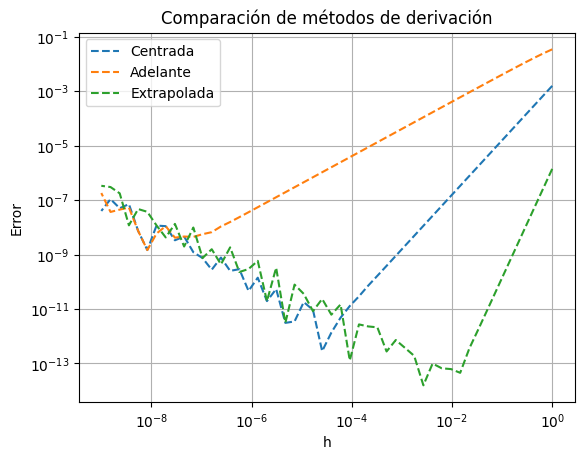

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("resultado_2.txt", delim_whitespace=True, header=None)

df.columns = ["h", "centrada", "adelante", "extrapolada"]


plt.plot(df["h"], df["centrada"], label="Centrada", linestyle="--")
plt.plot(df["h"], df["adelante"], label="Adelante", linestyle="--")
plt.plot(df["h"], df["extrapolada"], label="Extrapolada", linestyle="--")


plt.xscale("log")
plt.yscale("log")

plt.grid()
plt.legend()
plt.xlabel("h")
plt.ylabel("Error")
plt.title("Comparación de métodos de derivación")
plt.show()
